In [1]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
import pickle
import datetime
from tqdm import tqdm
from matplotlib.pyplot import cm
import numpy as np
from hardware.timetagger_counter import HWRecorderMode
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!

In [2]:
def setup_autoapproach():
    #configuration of autoapproach settings
    # for HFAmpl signal

    threshold = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_SETP_DISP')) / 1e7
    spm._dev.aap.setAApThreshold(threshold)

    # dF     8
    # HFAmpl       13
    input_signal = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_INPUT'))
    threshold_cond = 1 if input_signal==13 else 0        
    spm._dev.aap.setAApStopCondition(threshold_cond) # [0, 1] >threshold/<threshold
    spm._dev.aap.setAApStepsPerApproach(0)

    spm._dev.aap.setAApAproachMode(1) # [0, 1] Ramp/Loop
    spm._dev.aap.setAApModeAfter(0) # [0, 1, 2] On/Retract/Off

def get_pos(reps=5):
    pos = 0
    for i in range(reps):
        pos = pos+ spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return pos/reps

def go_into_contact():
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_AAP_CTRL'), 1, 0)
    while not spm.is_probe_landed():
        time.sleep(0.001)
    time.sleep(0.5)
        
def do_lift_off(lift_off_height):
    pos = get_pos()
    new_pos = pos - lift_off_height
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_LOOP_ON'), 0, 0)
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), new_pos*1e12, 0)

def _grabASCData(chnNo, bufSize):
    while True:
            # Wait until buffer is full
        if spm._dev.base.waitForFullBuffer(chnNo) != 0:
                break
    buffer = spm._dev.base.getDataBuffer(chnNo, 0, bufSize)
    values = buffer[3][:]
    meta = buffer[4]
    phys_vals = []
    unit = spm._dev.base.getUnitVal(meta)
    scaling = 1
    if 'Milli' in unit:
        scaling = 1e-3
    for val in values:
        phys_vals.append(spm._dev.base.convValue2Phys(meta, val)*scaling)
    return np.mean(phys_vals)    
    
def get_spm_channel_data(channel="CHANADC_AFMAMPL"):
    """Look in to the header file asc500.h for all the channel names"""
    spm._dev.base.configureChannel(11, # any Number between 0 and 13.
                            spm._dev.base.getConst('CHANCONN_PERMANENT'), # How you want to the data to be triggered
                            spm._dev.base.getConst('CHANADC_AFMAMPL'), #The Channel you want to get the data from
                            1, # 0/1 -  if you want to switch on averaging
                            1e-3) # Scanner sample time [s]
    spm._dev.base.configureDataBuffering(11, 256) # chNo = same as above; bufSize = Buffersize.
    # MAKE SURE BUFFER SIZE IS GREATER THAN 128 FOR TIME TRIGGERED DATA
    return _grabASCData(11, 256)

def setup_counter(max_sweeps):
    ret_val = afm_scanner_logic._counter.configure_recorder(
                mode=HWRecorderMode.GENERAL_PULSED,
                params={'laser_pulses': 1,
                        'bin_width_s': podmrlogic.bin_width_s,
                        'record_length_s': podmrlogic.record_length_s,
                        'max_counts': int(max_sweeps)} )
    
def run_measurement():
    afm_scanner_logic._counter.start_recorder(arm=True)
    #Start pulsed measurement
    afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_on()
    # obtain pulsed measurement
    pulsed_meas = afm_scanner_logic._counter.get_measurements()[0] # this is the blocking statement
    afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_off()
    return pulsed_meas

#### Define general measurement params

In [3]:
#measurement parameters
laser_power_voltage = 0.0 #podmrlogic.laser_power_voltage

#Driving information for the first LO (SMBV)
target_freq_0 = 3.15034e9
LO_freq_0 = target_freq_0 + 100e6
power_0 = 0
pi_pulse = 142e-9 

#For same NV rabi SGS is run with power_1 = power_0 - 11dBm
#Driving information for the second LO (SGS)
target_freq_1 = 2.87e9
LO_freq_1 = target_freq_1 + 100e6
power_1 = -100
pi_pulse_1 = 72e-9

switch_MW = False #If True, MW1 is used as the main MW source

#additional information for save tag
tip_name = 'A-T16-25'
sample = 'Tommy2'
temperature = 'RT'
b_field = 'mag_-25um_new'
contact = 'OOC'
res_freq = 195e3
extra = f'{res_freq/1e3}kHz_FC_ON_AC_Off'

#### Load and ready PL Osc. sequence

In [4]:
Aexc_arr = np.linspace(0.05, 0.3, 7)
# Aexc_arr = [0.1, 0.15, 0.2, 0.25, 0.3] #in V

wait_bw_TF_set = 2

t0_start = 1e-6
t0_stop = 10e-6
t0_num = 30

max_sweeps = 500e3

afm_scanner_logic.jupyter_meas_stop = False

meas_dict = {}
afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_off()
setup_counter(max_sweeps)

for Aexc in Aexc_arr:
    t0_sweep_init = np.linspace(t0_start, t0_stop, t0_num)
    t0_sweep = np.zeros_like(t0_sweep_init)
    data_arr = np.zeros((len(t0_sweep_init),int(podmrlogic.record_length_s/podmrlogic.bin_width_s)))
          
    spm._dev.afm.setTFExcitationAmplitude(Aexc)
    time.sleep(wait_bw_TF_set)
    
    with tqdm(t0_sweep_init) as progress_bar:
        for i, t_0 in enumerate(progress_bar):
            progress_bar.set_description(f"Measuring {round(Aexc*1000,3)}mV...")
            pjl.initialize_ensemble(laser_power_voltage = laser_power_voltage,  
                trigger_type = 'pos_edge_rearm', trigger_level0 = 400, 
                trigger_level1 = -200, set_up_measurement = False, printing = False)

            ret = pjl.PL_Osc_gradiometry(t_0)
            t0_sweep[i] = ret[5] # Actual T_0 time used
            
            data = run_measurement()
            data_arr[i] = data
                     
            if afm_scanner_logic.jupyter_meas_stop:
                break
            
    if afm_scanner_logic.jupyter_meas_stop:
            break

    meas_dict[Aexc] = {"t0_sweep": t0_sweep.copy(), 
                         "data_raw": data_arr.copy(),
                         "max_sweeps": max_sweeps,
                         'bin_width_s': podmrlogic.bin_width_s,
                         'HF_Ampl': get_spm_channel_data(channel="CHANADC_AFMAMPL")
                        }
    
string = datetime.datetime.now().isoformat('_','seconds')+'_'+'PL_Osc_Exc_sweep'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)

Measuring 50.0mV...: 100%|#| 30/30
Measuring 91.667mV...: 100%|#| 30/
Measuring 133.333mV...: 100%|#| 30
Measuring 175.0mV...: 100%|#| 30/3
Measuring 216.667mV...: 100%|#| 30
Measuring 258.333mV...: 100%|#| 30
Measuring 300.0mV...: 100%|#| 30/3


#### Load and ready Gradiometry sequence with lift off

Pickle load

In [5]:
root = r"D:\Data\RT_AFM_Data\2025\08\20250805\Lock-In-Tip"
path = root +"\\"+ "2025-08-05_13-50-49_PL_Osc_Exc_sweep_A-T16-25_195.0kHz_FC_ON_AC_Off" 
with open(path+'.pickle', 'rb') as f:
    data = pickle.load(f)

In [6]:
from logic.pulsed.pulsed_analysis_methods.basic_analysis_methods import BasicPulseAnalyzer
Analyzer = BasicPulseAnalyzer(pulsedmeasurementlogic_AWG)
pulsedmeasurementlogic_AWG.set_fast_counter_settings({"bin_width":1e-9})

{'bin_width': 1e-09, 'record_length': 3e-06, 'number_of_gates': 4, 'is_gated': True}

In [7]:
import matplotlib as mpl
from uncertainties import ufloat
from uncertainties import unumpy
from uncertainties import umath
from lmfit import Model

def osc_under_gaussian(t0, Cm0, A, B, f_tf, beta):
    """Oscillator under a gaussian beam.
    Cm,0 is the counts when stationary, A and B are shape parameters depending on
    the offset and strength of the oscillation, and β is a delay
    """
    P = -(A + B * np.sin(2 * np.pi * f_tf * t0 + beta))**2
    return Cm0 * np.exp(P)

gmodel = Model(osc_under_gaussian)
params = gmodel.make_params()
print(params)

def analyse_sum(data):
    sig = np.zeros((len(data)))
    err = np.zeros((len(data)))
    for i, d in enumerate(data):
        ret = Analyzer.analyse_sum(np.array([d]), 200e-9, 400e-9)
        sig[i] = ret[0]
        err[i] = ret[1]
    return unumpy.uarray(sig, err)

Parameters([('Cm0', <Parameter 'Cm0', -inf, bounds=[-inf:inf]>), ('A', <Parameter 'A', -inf, bounds=[-inf:inf]>), ('B', <Parameter 'B', -inf, bounds=[-inf:inf]>), ('f_tf', <Parameter 'f_tf', -inf, bounds=[-inf:inf]>), ('beta', <Parameter 'beta', -inf, bounds=[-inf:inf]>)])


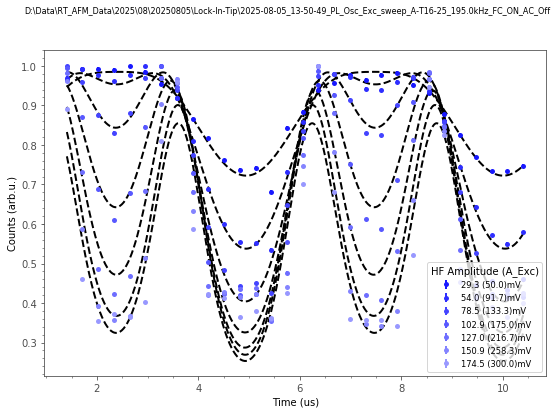

In [12]:
fig, ax1 = plt.subplots(1,1)

cm = plt.get_cmap('bwr')
cl = cm(list(data.keys()))

for i, key in enumerate(data.keys()):
#     if i>3:
#         continue
    t0_sweep = data[key]["t0_sweep"]*1e6
    data_raw = data[key]["data_raw"]
    ret = analyse_sum(data_raw)
    counts = ret/ret.max()
    color = mpl.colors.rgb2hex(cl[i], keep_alpha=True)
    
    result = gmodel.fit(unumpy.nominal_values(counts), t0=t0_sweep, Cm0=1, A=1, B=1, f_tf=195e3*1e-6, beta=1)
    
    ax1.errorbar(x=t0_sweep, y=unumpy.nominal_values(counts),
                             yerr=unumpy.std_devs(counts),color=color,mec=color, 
                             label=f'{round(data[key]["HF_Ampl"]*1e3,1)} ({round(key*1e3,1)})mV', fmt='o', markersize=5)
    t0_sweep_dense = np.linspace(t0_sweep[0], t0_sweep[-1], 500)
    temp = gmodel.eval(result.params, t0=t0_sweep_dense)
    ax1.plot(t0_sweep_dense, temp, 'k--')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Counts (arb.u.)')
plt.legend(title="HF Amplitude (A_Exc)", loc=4, fontsize='small', fancybox=True)
fig.suptitle(f'{path}', fontsize=8)
plt.savefig(path+'.png', dpi=900)
plt.show()